# Visualizaciones del informe ejecutivo

**82.04 Analítica Descriptiva — ITBA**

Los tres gráficos que acompañan el informe de la primera pre-entrega, generados a
partir de `data/raw/dataset_maestro.csv`.

Cada uno responde una pregunta concreta del informe, no está por decoración:

| Gráfico | Qué sustenta |
|---|---|
| Distribución de precios | Que el perfil de cliente elegido tiene un universo real de oferta |
| Cobertura por barrio | Que el relevamiento alcanza toda la ciudad |
| Completitud | Que las variables de interés se capturaron efectivamente |

Los PNG se guardan en `graficos/` para poder insertarlos en el informe.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("../graficos", exist_ok=True)

df = pd.read_csv("../data/raw/dataset_maestro.csv", encoding="utf-8-sig", low_memory=False)
print(f"{df.shape[0]:,} avisos x {df.shape[1]} variables")

14,867 avisos x 55 variables


## Estilo común

Se define una vez para que los tres gráficos sean visualmente consistentes.

Criterios: sin bordes superiores ni derechos, grilla tenue por detrás de los datos,
y una paleta de dos colores donde el naranja marca lo que hay que mirar.

In [2]:
AZUL = "#2a78d6"
NARANJA = "#eb6834"
GRIS = "#52514E"

plt.rcParams.update({
    "font.size": 9,
    "axes.edgecolor": "#C3C2B7",
    "axes.labelcolor": GRIS,
    "text.color": GRIS,
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "figure.dpi": 110,
})


def limpiar_ejes(ax, lados=("top", "right")):
    """Saca los bordes que no aportan información."""
    for s in lados:
        ax.spines[s].set_visible(False)
    ax.set_axisbelow(True)   # la grilla va detrás de las barras

## 1. Distribución de precios de venta

**Pregunta que responde:** ¿el pequeño inversor, con ahorros de entre USD 80.000 y
200.000, tiene un universo real de oferta donde elegir?

Se filtra a operaciones de venta en dólares. El corte en USD 600.000 es solo visual:
la cola derecha es tan larga que sin recortarla el histograma se vuelve ilegible.

In [3]:
vta = df[(df.operacion == "venta") &
         (df.precio_moneda == "USD") &
         df.precio_valor.notna()]

mediana = vta.precio_valor.median()
pct_accesible = (vta.precio_valor < 150_000).mean() * 100

print(f"Ventas en USD        : {len(vta):,}")
print(f"Mediana              : USD {mediana:,.0f}")
print(f"Bajo USD 150.000     : {pct_accesible:.1f}%")
print()
print(vta.precio_valor.describe(percentiles=[.1, .25, .5, .75, .9]).round(0).to_string())

Ventas en USD        : 13,035
Mediana              : USD 130,000
Bajo USD 150.000     : 57.4%

count       13035.0
mean       187909.0
std        266892.0
min          3500.0
10%         57000.0
25%         84830.0
50%        130000.0
75%        214000.0
90%        348000.0
max      12000000.0


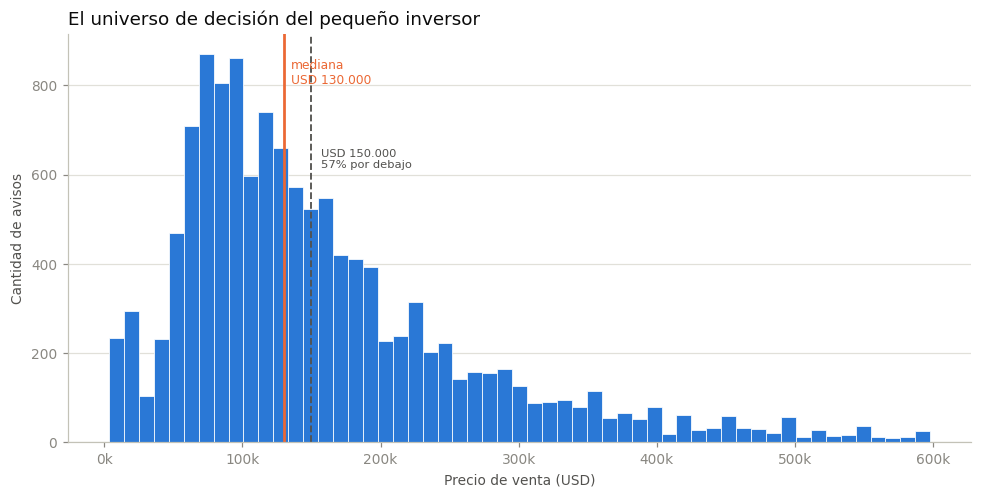

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.6))

p = vta[vta.precio_valor < 600_000].precio_valor
ax.hist(p, bins=55, color=AZUL, edgecolor="white", linewidth=0.5)

# referencia 1: la mediana del mercado
ax.axvline(mediana, color=NARANJA, linewidth=1.8)
ax.text(mediana * 1.04, ax.get_ylim()[1] * 0.88,
        f"mediana\nUSD {mediana:,.0f}".replace(",", "."),
        fontsize=8, color=NARANJA)

# referencia 2: el techo del perfil de cliente
ax.axvline(150_000, color=GRIS, linestyle="--", linewidth=1.2)
ax.text(157_000, ax.get_ylim()[1] * 0.72,
        f"USD 150.000\n{pct_accesible:.0f}% por debajo",
        fontsize=7.5, color=GRIS, va="top")

ax.set_xlabel("Precio de venta (USD)")
ax.set_ylabel("Cantidad de avisos")
ax.set_title("El universo de decisión del pequeño inversor",
             loc="left", fontsize=12, color="#0b0b0b")
ax.xaxis.set_major_formatter(lambda x, _: f"{x/1000:.0f}k")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
limpiar_ejes(ax)

plt.tight_layout()
plt.savefig("../graficos/precios.png", dpi=190, bbox_inches="tight")
plt.show()

**Lectura.** La distribución tiene una asimetría positiva marcada: la mayor parte de
la oferta se concentra por debajo de la mediana y una cola derecha larga corresponde
al segmento premium.

El dato que importa para el informe es que el **59% de la oferta queda por debajo de
los USD 150.000**, lo que confirma que el perfil de cliente elegido tiene un universo
amplio donde elegir. Si ese porcentaje fuera bajo, el análisis no le serviría.

## 2. Cobertura del relevamiento por barrio

**Pregunta que responde:** ¿el relevamiento cubre toda la ciudad o quedó sesgado hacia
unas pocas zonas?

Se muestran los 20 barrios con más avisos. La cobertura completa —48 de 48— se reporta
aparte, porque en un gráfico de barras los barrios con pocos avisos serían ilegibles.

In [5]:
print(f"Barrios cubiertos : {df.barrio.nunique()} de 48")
print(f"Comunas cubiertas : {int(df.comuna.nunique())} de 15")
print(f"Sin barrio asignado: {df.barrio.isna().sum()}")
print()

por_barrio = df.barrio.value_counts()
print(f"Mediana de avisos por barrio : {por_barrio.median():.0f}")
print(f"Barrio con menos avisos      : {por_barrio.idxmin()} ({por_barrio.min()})")

Barrios cubiertos : 48 de 48
Comunas cubiertas : 15 de 15
Sin barrio asignado: 0

Mediana de avisos por barrio : 192
Barrio con menos avisos      : villa riachuelo (27)


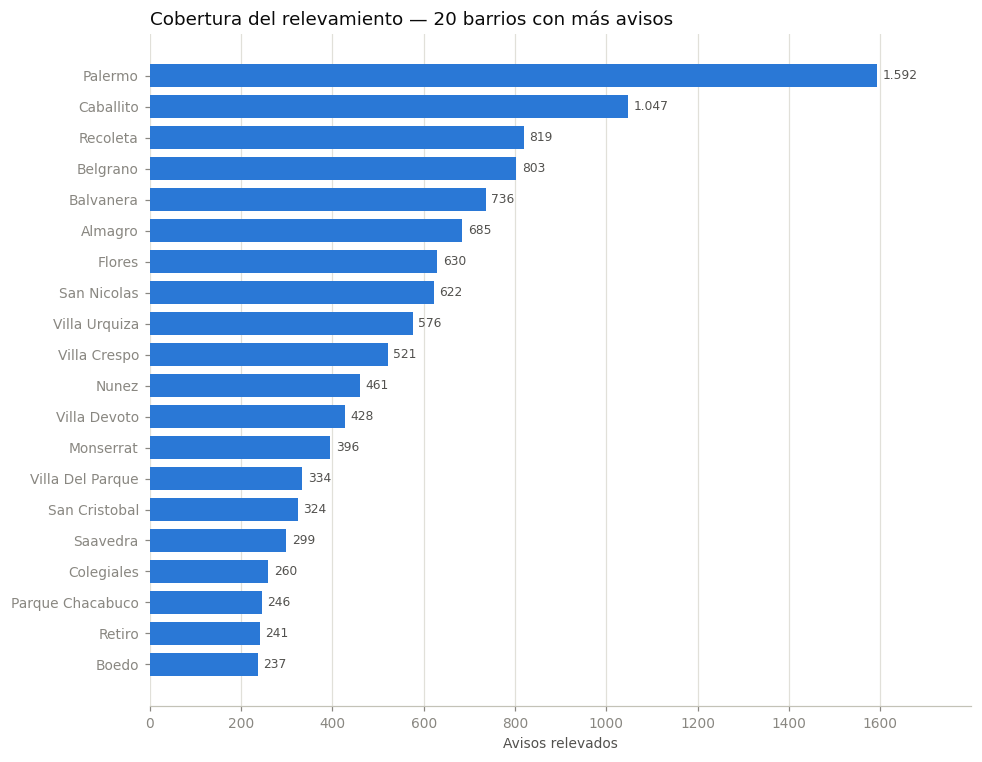

In [6]:
top = por_barrio.head(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index.str.title(), top.values, color=AZUL, height=0.72)

for i, v in enumerate(top.values):
    ax.text(v + 12, i, f"{v:,}".replace(",", "."),
            va="center", fontsize=8, color=GRIS)

ax.set_xlabel("Avisos relevados")
ax.set_title("Cobertura del relevamiento — 20 barrios con más avisos",
             loc="left", fontsize=12, color="#0b0b0b")
ax.set_xlim(0, top.max() * 1.13)
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)
limpiar_ejes(ax, ("top", "right", "left"))

plt.tight_layout()
plt.savefig("../graficos/barrios.png", dpi=190, bbox_inches="tight")
plt.show()

**Lectura.** La concentración en Palermo, Caballito, Recoleta y Belgrano refleja la
distribución real de la oferta inmobiliaria de CABA, no un sesgo del scraping: son los
barrios con más movimiento del mercado.

Lo relevante es que **los 48 barrios están representados**, lo que permite comparaciones
entre zonas sin huecos. Los barrios con pocos avisos van a requerir cautela en las
etapas de análisis, y ese límite queda declarado.

## 3. Completitud de las variables de interés

**Pregunta que responde:** ¿las variables que el proyecto declaró como necesarias se
capturaron efectivamente?

Se marcan en naranja las que quedan por debajo del 90%, el umbral a partir del cual la
variable empieza a requerir tratamiento de faltantes.

In [7]:
CLAVE = ["barrio", "sup_total_m2", "dormitorios", "banos", "descripcion",
         "latitud", "precio_valor", "antiguedad_anios", "expensas_valor",
         "ambientes"]

completitud = (df[CLAVE].notna().mean() * 100).sort_values()

pd.DataFrame({
    "no nulos": df[CLAVE].notna().sum(),
    "% completitud": completitud.round(1),
}).sort_values("% completitud", ascending=False)

,no nulos,% completitud
barrio,14867,100.0
banos,14867,100.0
sup_total_m2,14867,100.0
dormitorios,14867,100.0
descripcion,14867,100.0
latitud,14858,99.9
precio_valor,14794,99.5
antiguedad_anios,14527,97.7
expensas_valor,13859,93.2
ambientes,12829,86.3


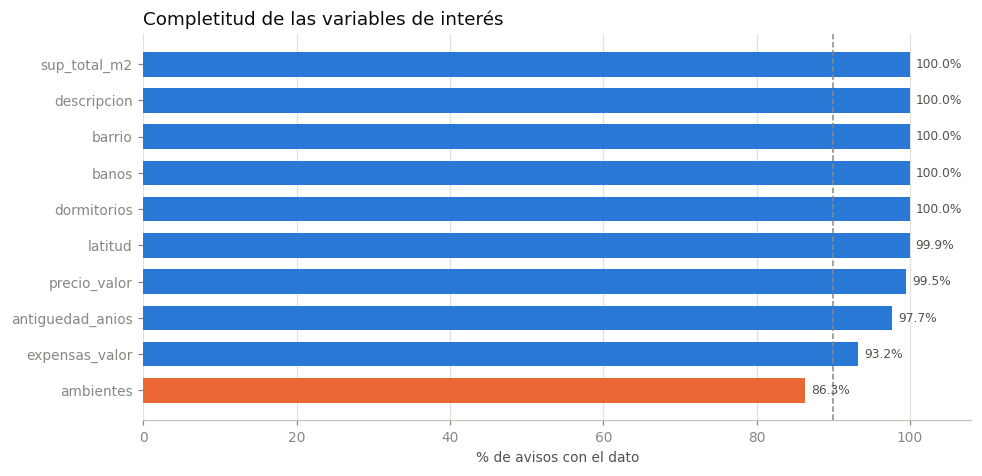

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.4))

colores = [NARANJA if v < 90 else AZUL for v in completitud.values]
ax.barh(completitud.index, completitud.values, color=colores, height=0.68)

for i, v in enumerate(completitud.values):
    ax.text(v + 0.8, i, f"{v:.1f}%", va="center", fontsize=8, color=GRIS)

ax.axvline(90, color="#898781", linestyle="--", linewidth=1)
ax.set_xlabel("% de avisos con el dato")
ax.set_xlim(0, 108)
ax.set_title("Completitud de las variables de interés",
             loc="left", fontsize=12, color="#0b0b0b")
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)
limpiar_ejes(ax, ("top", "right", "left"))

plt.tight_layout()
plt.savefig("../graficos/completitud.png", dpi=190, bbox_inches="tight")
plt.show()

**Lectura.** Las variables estructurales —barrio, superficie, dormitorios, baños— están
completas o casi. Las coordenadas al 99,9% son la base de los cruces espaciales
previstos.

`ambientes` es la que más falta, y tiene una explicación: los monoambientes suelen
publicarse sin declarar la cantidad de ambientes, porque está implícita en la tipología.
Es un faltante **sistemático**, no aleatorio, y se tratará en la etapa de curaduría.

**Nota metodológica importante.** Esta completitud es consecuencia de haber ejecutado el
scraping con el flag `--detalle`, que entra a cada ficha individual. Una primera corrida
sin ese flag dejó cinco variables completamente vacías, entre ellas la antigüedad del
edificio, que es una de las variables de interés declaradas del proyecto.

## Verificación de los archivos generados

In [9]:
for f in sorted(os.listdir("../graficos")):
    tam = os.path.getsize(f"../graficos/{f}") / 1024
    print(f"  {f:<20} {tam:>6.0f} KB")

  barrios.png             122 KB
  completitud.png          82 KB
  precios.png              59 KB
